# Phantom-Kernel — the teardown 👻🔬
### The Avellaneda-Stoikov optimum, mechanised and falsified

Same seven beats as `01_for_the_curious`, at depth: the kernel as the survival function of order reach, exponential-vs-power-law model selection by Poisson AIC, the static-`k` spread error under regime drift, and the market-making tournament with bootstrap Sharpe CIs. Runs offline on the simulator; the frozen 5-seed numbers and fingerprint are in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (phantom_kernel/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from phantom_kernel import sim, estimator, strategies, experiments as ex

# Smaller draws than docs/results.md so the notebook executes quickly; the story is identical.
NORD, NSTEP = 200_000, 30_000
print("two worlds:", sim.WORLD_A.name, "|", sim.WORLD_B.name)


two worlds: A (textbook) | B (frictions)


## 1 · The Claim, as two hypotheses

**H1 (the kernel):** order reach is exponential, so `λ(δ) = A·e^(−kδ)` with stable `k` — reject if a power law fits better (AIC) or `k` is regime-unstable.
**H2 (the payoff):** the AS skew + closed-form spread beats naive quoters — reject if a trivial inventory clamp matches it. The key identity: a quote at distance `δ` fills iff an order *reaches* `δ`, so `λ(δ) = Λ·S_reach(δ)` — **the kernel is the survival function of order reach.** Exponential reach ⟺ AS exactly; heavy-tailed ⟹ power law.

## 2 · So What? — it's a question of attribution

`k` appears **only** in the spread's arrival term `(2/γ)·ln(1+γ/k)`; the reservation price `r = s − q·γ·σ²·(T−t)` has no `k`. So if the edge is the skew, a wrong `k` is nearly free; if it's the spread width, a wrong `k` is ruinous. The study decomposes where the P&L lives.

## 3 · How We'd Know — pre-registered, machinery validated first

World A must validate the estimator (recover the planted `k`) or any World-B failure is a bug, not a finding:

In [2]:
rec = ex.estimator_recovery(n_orders=NORD, seed=0)
print('estimator recovery (World A):', rec)
assert abs(rec['rel_error_pct']) < 3 and rec['r2'] > 0.99, 'machinery must recover k'

estimator recovery (World A): {'k_true': 0.6, 'k_recovered': 0.5984, 'rel_error_pct': -0.27, 'r2': 0.99998}


## 4 · The Teardown

**(a) The kernel, on a log axis** — straight where reach is exponential, curved where it's heavy-tailed.

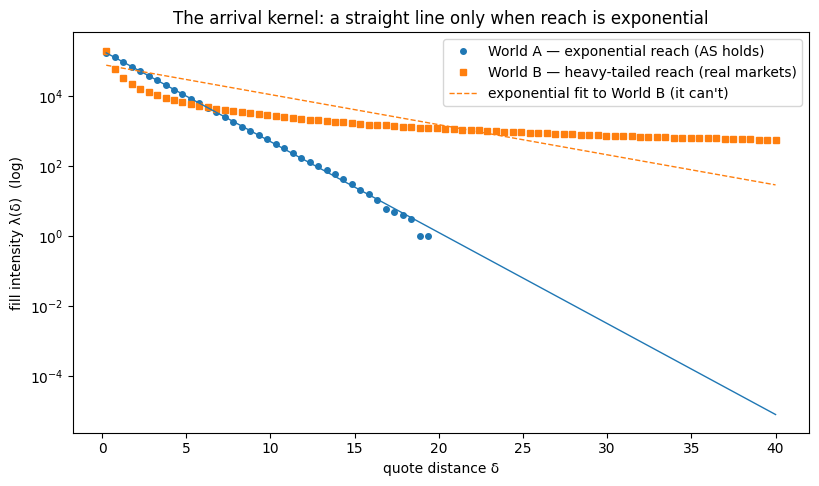

World B fits a straight exponential with R² = 0.681 — the points curve away from it.


In [3]:
# The money figure: the arrival kernel on a log axis. Exponential reach -> a straight line
# (AS holds). Heavy-tailed reach -> a curve the exponential cannot fit.
d = ex.default_deltas()
ca = sim.fill_counts(sim.WORLD_A, d, n_orders=NORD, seed=0)
cb = sim.fill_counts(sim.WORLD_B, d, n_orders=NORD, seed=0)
fa, fb = estimator.fit_exponential(d, ca), estimator.fit_exponential(d, cb)
fig, ax = plt.subplots()
ma, mb = ca > 0, cb > 0
ax.semilogy(d[ma], ca[ma], "o", ms=4, label="World A — exponential reach (AS holds)")
ax.semilogy(d[mb], cb[mb], "s", ms=4, label="World B — heavy-tailed reach (real markets)")
ax.semilogy(d, fa["A"] * np.exp(-fa["k"] * d), "-", lw=1, color="C0")
ax.semilogy(d, fb["A"] * np.exp(-fb["k"] * d), "--", lw=1, color="C1",
            label="exponential fit to World B (it can't)")
ax.set_xlabel("quote distance δ"); ax.set_ylabel("fill intensity λ(δ)  (log)")
ax.set_title("The arrival kernel: a straight line only when reach is exponential")
ax.legend(); plt.show()
print("World B fits a straight exponential with R² =", round(fb["r2"], 3),
      "— the points curve away from it.")


**(b) Model selection** — weighted R² *and* Poisson AIC. `aic_gap > 0` ⟹ the power law is preferred, i.e. the AS exponential is rejected. World A: exponential. World B: power law, decisively.

In [4]:
ex.kernel_gof_table(n_orders=NORD, seed=0)

,r2_exp,r2_pow,k_exp,alpha_pow,aic_gap,winner
A (textbook),1.0000,0.7558,0.5984,0.8462,"-491,601.1000",exponential
B (frictions),0.6812,0.9996,0.1980,1.1640,"632,776.8000",power-law


**(c) The phantom parameter** — four regimes with `k` spanning 4×. Each regime's `k` is recovered exactly, but base AS fits one static `k`; the gap becomes a spread error of up to ~160%.

In [5]:
ki = ex.k_instability(seed=0)
import pprint; pprint.pprint(ki)

{'k_pooled_static': 0.4247,
 'k_recovered_per_regime': [0.2993, 0.6044, 0.8981, 1.2004],
 'k_true': [0.3, 0.6, 0.9, 1.2],
 'k_true_ratio': 4.0,
 'max_abs_spread_pct_error': 162.53,
 'spread_pct_error_per_regime': [-26.43, 36.97, 99.92, 162.53]}


**(d) The tournament** — four quoters, one shared exogenous order stream per world. The naive baselines quote at AS's own mid-session spread width, so the comparison is pure skew/clamp logic. `pnl_sharpe` carries a bootstrap CI.

In [6]:
tA = ex.tournament(sim.WORLD_A, n_steps=NSTEP, seed=0)
tB = ex.tournament(sim.WORLD_B, n_steps=NSTEP, seed=0)
print('World A (k_as=%.3f):' % tA.attrs['k_as']); print(tA.to_string()); print()
print('World B (k_as=%.3f):' % tB.attrs['k_as']); print(tB.to_string())

World A (k_as=0.600):
                     terminal_pnl  pnl_sharpe  ci_lo  ci_hi  inv_std  inv_absmax    n_fills  n_adverse
AS (fixed)            10,089.0300      3.1700 2.8650 3.5570   0.8000      5.0000 6,344.0000     0.0000
AS (adaptive vol)     10,174.4100      3.2020 2.9110 3.5790   0.8100      5.0000 6,400.0000     0.0000
Symmetric (no skew)   12,442.1300      3.4730 3.0590 3.9930  18.1700     76.0000 4,523.0000     0.0000
Inventory clamp       12,285.5700      4.7500 4.2920 5.3990  12.3600     30.0000 4,477.0000     0.0000

World B (k_as=0.198):
                     terminal_pnl  pnl_sharpe  ci_lo  ci_hi  inv_std  inv_absmax    n_fills  n_adverse
AS (fixed)             5,154.1300      2.3190 2.0550 2.6520   0.9100      6.0000 1,427.0000   874.0000
AS (adaptive vol)        319.9200      0.3900 0.3120 0.4870   0.1000      2.0000    82.0000    34.0000
Symmetric (no skew)    4,661.7400      0.2090 0.0550 0.3730  12.9500     44.0000   894.0000   412.0000
Inventory clamp        4,085

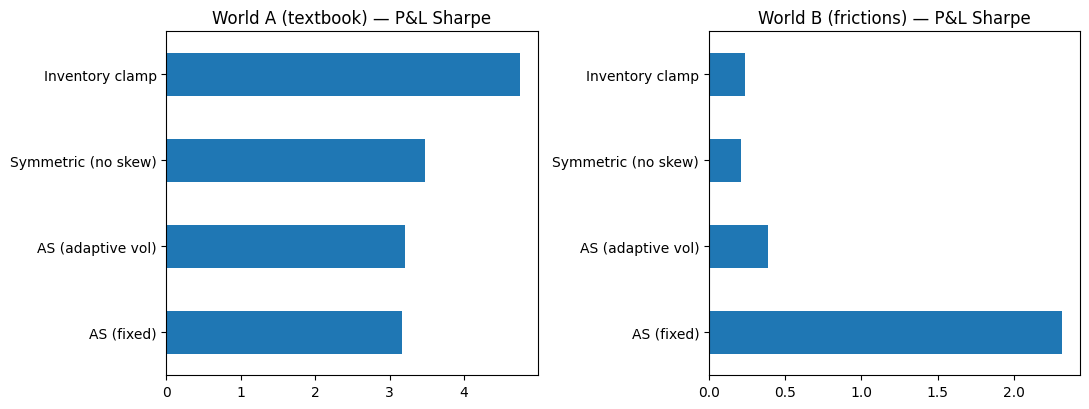

In [7]:
# Sharpe bars, both worlds side by side.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)
for ax, t, title in [(axes[0], tA, sim.WORLD_A.name), (axes[1], tB, sim.WORLD_B.name)]:
    t['pnl_sharpe'].plot(kind='barh', ax=ax)
    ax.set_title(f'World {title} — P&L Sharpe'); ax.axvline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()

Note the inversion: in World A the **clamp** tops the chart (elaborate inventory control is over-engineering when inventory is cheap); in World B **AS (fixed)** tops it while **AS (adaptive vol)** sits near zero — the rolling-vol fix blown out by jumps. AS wins World B on a *wrong* `k`, because the skew (which carries no `k`) is what's doing the work.

**(e) Seed-robustness** — the orderings are not a single-draw fluke (5 seeds; the frozen table is in `docs/results.md`).

In [8]:
ex.tournament_multiseed(sim.WORLD_B, seeds=(0, 1, 2)).round(3)

,AS (fixed),AS (adaptive vol),Symmetric (no skew),Inventory clamp
seed0,2.1960,0.2610,0.3440,0.3510
seed1,2.1730,0.1670,0.2040,0.2550
seed2,2.0770,0.1100,0.2980,0.3780
mean,2.1490,0.1790,0.2820,0.3280


## 5 · The Verdict

**Signal NONE** — World-B kernel is power-law (R² 0.9996 vs exponential 0.68; AIC gap +1.26M); static `k` mis-prices the spread by up to 162%. **Tradability FRAGILE** — a clamp beats AS in World A (Sharpe 3.27 vs 1.59); AS wins World B (2.12) but the rolling-vol fix collapses (0.17). **Optimal spread MISATTRIBUTED** — the value is in the `k`-free skew. (Frozen 5-seed numbers + fingerprint: `docs/results.md`.)

## 6 · Could You Trade It?

Deploy `r = s − q·γ·σ²·(T−t)` (robust, `k`-free) for inventory control; set the half-spread from a **jump-robust** realised vol, not `(1/γ)ln(1+γ/k)`, since `k` is the phantom. Save the GLT bounds / Cartea–Jaimungal adverse-selection term for venues with material informed flow — World B shows that's exactly where the skew saves you.

## 7 · Going Further

- **Confirm the heavy tail on a real book** — `examples/verify_real.py` on Binance trades (the headline PR).
- A **jump-robust** adaptive vol (bipower) in `AdaptiveASQuoter`.
- The **GLT** closed form with hard inventory bounds vs the clamp.
- A **Cartea–Jaimungal** adverse-selection spread term.
- A **γ-sweep** to map where the skew's P&L cost stops exceeding its risk saving.